# Assignment 2

Max collaborators = 3

Hand holding is low for this assignment. Adjust accordingly. In case of confusion, feel free to reach out to your lab faculties. Good luck.

In [ ]:
# COLLABORATOR_1_NAME = " "
# COLLABORATOR_1_ID =  " "

In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
Available GPUs: []


# Loading dependencies

In [3]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt
#add if more dependencies are required here
import random
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings("ignore")

def enhance_images_for_cnn(images, name="dataset", strength=0.35, contrast=1.08):
    images = np.asarray(images).astype("float32")

    # Keep values in [0, 1]
    if images.max() > 1.0:
        images = images / 255.0

    images_tf = tf.convert_to_tensor(images, dtype=tf.float32)

    # Mild blur estimate, then sharpen by adding back the high-frequency details
    blurred = tf.nn.avg_pool2d(images_tf, ksize=3, strides=1, padding="SAME")
    enhanced = images_tf + strength * (images_tf - blurred)

    # Slight contrast improvement, then keep valid image range
    enhanced = tf.image.adjust_contrast(enhanced, contrast)
    enhanced = tf.clip_by_value(enhanced, 0.0, 1.0)

    enhanced = enhanced.numpy().astype("float32")
    print(f"{name} enhanced shape: {enhanced.shape}")
    return enhanced


# Loading dataset

In [ ]:
id = #insert id of any one collaborator in int

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train, y_train = sklearn.utils.resample(x_train, y_train, replace = False, n_samples = 5000, random_state = id, stratify = y_train)
x_test, y_test = sklearn.utils.resample(x_test, y_test, replace = False, n_samples = 1000, random_state = id, stratify = y_test)

# Task 1: Training a logistic regressor [10 Marks]

### 1. Convert the images to grayscale

In [5]:
def rgb2gray(images):
    # images shape: (n, h, w, 3)
    return np.dot(images[...,:3], [0.2989, 0.5870, 0.1140])

x_train_gray = rgb2gray(x_train).astype(np.float32)
x_test_gray = rgb2gray(x_test).astype(np.float32)

print('x_train_gray shape:', x_train_gray.shape)
print('x_test_gray shape:', x_test_gray.shape)

x_train_gray shape: (5000, 32, 32)
x_test_gray shape: (1000, 32, 32)


### 2. Prepare the grayscale images for logistic regressor (reshape and normalize)

Use z-score normalization.

In [6]:
# Flatten grayscale images
gray_train = x_train_gray.shape[0]
gray_test = x_test_gray.shape[0]
x_train_flat = x_train_gray.reshape(gray_train, -1).astype(np.float32)
x_test_flat = x_test_gray.reshape(gray_test, -1).astype(np.float32)

# Compute z-score stats ONLY from training set
mean = x_train_flat.mean(axis=0)
std = x_train_flat.std(axis=0)

# Avoid division by zero
std[std == 0] = 1.0

# Apply z-score normalization
x_train_flat = (x_train_flat - mean) / std
x_test_flat = (x_test_flat - mean) / std

print('x_train_flat shape:', x_train_flat.shape)
print('x_test_flat shape:', x_test_flat.shape)

x_train_flat shape: (5000, 1024)
x_test_flat shape: (1000, 1024)


### 3. Create a validation set (20%)

In [7]:
y_train_flat = y_train.reshape(-1).astype(int)

X_train, X_val, y_train_final, y_val = train_test_split(
    x_train_flat, y_train_flat, test_size=0.2, random_state=id, stratify=y_train_flat,
)

print('Training set:', X_train.shape, y_train_final.shape)
print('Validation set:', X_val.shape, y_val.shape)

Training set: (4000, 1024) (4000,)
Validation set: (1000, 1024) (1000,)


### 4. Compute class weights

Go through this link - https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

In [8]:
classes = np.unique(y_train_final)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_final)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}

### 5. Run the logistic regressor

Use L2 regularizer. Find the C hyperparameter value through grid search. Pick the testing values according to your understanding. Use at least 3 test values and at max 5. Use the computed class weights while training your model.

In [ ]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}

base_clf = LogisticRegression(
    penalty='l2',
    solver='saga',
    multi_class='multinomial',
    max_iter=2000,
    class_weight=class_weight_dict,
    n_jobs=-1,
    random_state=id
)

gs = GridSearchCV(
    base_clf,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train, y_train_final)

print("Best params:", gs.best_params_)
print("Best CV score:", gs.best_score_)

best_clf = gs.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params: {'C': 0.001}
Best CV score: 0.2759947858028975


### 6. Evaluate the logistic regressor on the test set

In [10]:
y_test_flat = y_test.reshape(-1).astype(int)
y_pred = best_clf.predict(x_test_flat)

print('Test accuracy:', accuracy_score(y_test_flat, y_pred))
print('\nClassification report:\n', classification_report(y_test_flat, y_pred))

Test accuracy: 0.27

Classification report:
               precision    recall  f1-score   support

           0       0.36      0.31      0.33       100
           1       0.26      0.27      0.26       100
           2       0.24      0.24      0.24       100
           3       0.17      0.14      0.15       100
           4       0.23      0.23      0.23       100
           5       0.24      0.26      0.25       100
           6       0.26      0.31      0.28       100
           7       0.27      0.22      0.24       100
           8       0.26      0.29      0.28       100
           9       0.39      0.43      0.41       100

    accuracy                           0.27      1000
   macro avg       0.27      0.27      0.27      1000
weighted avg       0.27      0.27      0.27      1000



### 7. Write code to pick up a random image from the test set and display it

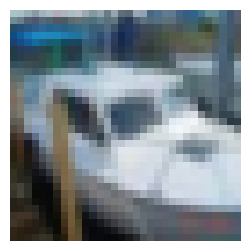

In [11]:
idx = random.randrange(x_test.shape[0])
plt.figure(figsize=(3,3))
plt.imshow(x_test[idx])
plt.axis('off')
true_label = int(y_test.reshape(-1)[idx])
pred_label = int(best_clf.predict(x_test_flat[idx].reshape(1, -1))[0])
plt.show()

### 8. Print the predicted class vs the original class

Do not print out the numerical class. Map it from here - https://keras.io/2/api/datasets/cifar10/

In [12]:
cifar_labels = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print(f"Original Class: {cifar_labels[true_label]}")
print(f"Predicted Class: {cifar_labels[pred_label]}")

Original Class: ship
Predicted Class: bird


# Task 2: Training a convolutional neural network [20 Marks]

We will not strictly control how you implement this code. You can use either Tensorflow or PyTorch. However the structure of the network must be -

```
Input -> Conv1 -> Conv2 -> Conv3 -> Fully Connected 1 -> Fully Connected 2 -> Output
```

Use activation functions and pooling as you want. Feel free to adjust dimensions as you need. Set the hyperparameters yourself. Use a maximum learning rate of 0.01 and a maximum epoch number of 100. Use AdamW as optimizer.

**Try achieving good accuracy. There are marks for that.**

### 1. Train the model on grayscale images

You do not need to use the validation set. Train on the initial train set. Recalculate the class weights again and pass it to the optimizer function. Normalize the images before processing.

In [23]:
# Define CNN model for grayscale images with lighter regularization
# Input -> Conv1 -> Conv2 -> Conv3 -> FC1 -> FC2 -> Output

# Reshape grayscale images for CNN (add channel dimension)
x_train_gray_cnn = x_train_gray.reshape(-1, 32, 32, 1).astype(np.float32)
x_test_gray_cnn = x_test_gray.reshape(-1, 32, 32, 1).astype(np.float32)

# Normalize to [0, 1]
x_train_gray_cnn = x_train_gray_cnn / 255.0
x_test_gray_cnn = x_test_gray_cnn / 255.0

# Improve blur/softness before CNN training/testing.
# Apply the same deterministic enhancement separately to train and test data.
x_train_gray_cnn = enhance_images_for_cnn(x_train_gray_cnn, name="Grayscale train")
x_test_gray_cnn = enhance_images_for_cnn(x_test_gray_cnn, name="Grayscale test")

# Get class labels for training data
y_train_flat_cnn = y_train.reshape(-1).astype(int)

# Recalculate class weights for the training set
classes_cnn = np.unique(y_train_flat_cnn)
class_weights_cnn = compute_class_weight('balanced', classes=classes_cnn, y=y_train_flat_cnn)
class_weight_dict_cnn = {int(c): float(w) for c, w in zip(classes_cnn, class_weights_cnn)}

# Milder data augmentation layer
data_augment = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomRotation(0.04),
    keras.layers.RandomZoom(0.04)
])

inputs = keras.Input(shape=(32,32,1))
x = data_augment(inputs)

# Conv block 1
x = keras.layers.Conv2D(32, (3,3), padding='same', use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)
x = keras.layers.Dropout(0.15)(x)

# Conv block 2
x = keras.layers.Conv2D(64, (3,3), padding='same', use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)
x = keras.layers.Dropout(0.15)(x)

# Conv block 3
x = keras.layers.Conv2D(128, (3,3), padding='same', use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)
x = keras.layers.Dropout(0.15)(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.Dropout(0.4)(x)
outputs = keras.layers.Dense(10, activation='softmax')(x)

model_gray = keras.Model(inputs=inputs, outputs=outputs)

model_gray.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Reduce LR on training-loss plateau
reduce_lr_gray = keras.callbacks.ReduceLROnPlateau(monitor='loss', mode='min', factor=0.5, patience=10, min_lr=1e-6)
# Early stopping on training loss (no validation set)
early_stop_gray = keras.callbacks.EarlyStopping(monitor='loss', mode='min', patience=15, restore_best_weights=True, verbose=1)

# Train on full grayscale training data
history_gray = model_gray.fit(
    x_train_gray_cnn, y_train_flat_cnn,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict_cnn,
    callbacks=[early_stop_gray, reduce_lr_gray],
    verbose=1,
)

# Training loss and accuracy display
train_loss_gray, train_acc_gray = model_gray.evaluate(x_train_gray_cnn, y_train_flat_cnn, verbose=0)
train_error_gray = 1 - np.exp(-train_loss_gray)
print(f"Training accuracy (grayscale): {train_acc_gray:.4f}")
print(f"Training sparse CE loss (grayscale): {train_loss_gray:.4f}")
print(f"Training smooth error 1-exp(-loss) (grayscale): {train_error_gray:.4f}")

Grayscale train enhanced shape: (5000, 32, 32, 1)
Grayscale test enhanced shape: (1000, 32, 32, 1)
Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2724 - loss: 2.1293 - learning_rate: 0.0100
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.3720 - loss: 1.7569 - learning_rate: 0.0100
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4280 - loss: 1.6480 - learning_rate: 0.0100
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4686 - loss: 1.5821 - learning_rate: 0.0100
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.4846 - loss: 1.5435 - learning_rate: 0.0100
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5056 - loss: 1.5105 - learning_rate: 0.0100
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5320 - loss: 1.4952 - learning_rate: 0.0100
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5350 - loss: 1.5019 - learning_rate: 0.0100
Epoch

### 2. Evaluate the model on the grayscale test set

In [24]:
y_test_flat_cnn = y_test.reshape(-1).astype(int)
y_pred_gray = model_gray.predict(x_test_gray_cnn).argmax(axis=1)

test_loss_gray, test_acc_gray = model_gray.evaluate(x_test_gray_cnn, y_test_flat_cnn, verbose=0)
test_error_gray = 1 - np.exp(-test_loss_gray)
print(f"Test accuracy (grayscale): {test_acc_gray:.4f}")
print(f"Test sparse CE loss (grayscale): {test_loss_gray:.4f}")
print(f"Test smooth error 1-exp(-loss) (grayscale): {test_error_gray:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Test accuracy (grayscale): 0.6800
Test sparse CE loss (grayscale): 1.6436
Test smooth error 1-exp(-loss) (grayscale): 0.8067


### 3. Write code to pick up a random image from the test set and display it

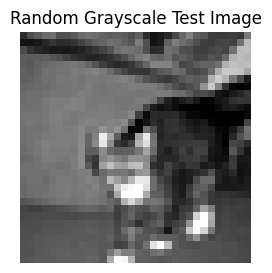

In [15]:
idx_gray = random.randrange(x_test_gray_cnn.shape[0])
plt.figure(figsize=(3, 3))
plt.imshow(x_test_gray_cnn[idx_gray].squeeze(), cmap='gray')
plt.axis('off')
plt.title('Random Grayscale Test Image')
plt.show()

### 4. Print the predicted class vs the original class

In [16]:
true_label_gray = int(y_test_flat_cnn[idx_gray])
pred_label_gray = int(y_pred_gray[idx_gray])

print(f"Original Class (Grayscale): {cifar_labels[true_label_gray]}")
print(f"Predicted Class (Grayscale): {cifar_labels[pred_label_gray]}")

Original Class (Grayscale): cat
Predicted Class (Grayscale): cat


### 5. Train the model on the RGB images

Keep the model same.

In [ ]:
# Build CNN model for RGB (same architecture, but input channels = 3) with milder regularization
x_train_rgb_full = x_train.reshape(-1, 32, 32, 3).astype(np.float32)
x_test_rgb = x_test.reshape(-1, 32, 32, 3).astype(np.float32)

# Normalize to [0, 1]
x_train_rgb_full = x_train_rgb_full / 255.0
x_test_rgb = x_test_rgb / 255.0

# Get class labels for training data
y_train_flat_rgb = y_train.reshape(-1).astype(int)

# Improve blur/softness before CNN training/testing.
# Apply the same deterministic enhancement separately to train and test data.
x_train_rgb = enhance_images_for_cnn(x_train_rgb_full, name="RGB train")
x_test_rgb = enhance_images_for_cnn(x_test_rgb, name="RGB test")

# Recalculate class weights for the training set
classes_rgb = np.unique(y_train_flat_rgb)
class_weights_rgb = compute_class_weight('balanced', classes=classes_rgb, y=y_train_flat_rgb)
class_weight_dict_rgb = {int(c): float(w) for c, w in zip(classes_rgb, class_weights_rgb)}

# Data augmentation (milder)
data_augment_rgb = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomRotation(0.04),
    keras.layers.RandomZoom(0.04)
])

inputs = keras.Input(shape=(32,32,3))
x = data_augment_rgb(inputs)

# Conv block 1
x = keras.layers.Conv2D(32, (3,3), padding='same', use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)
x = keras.layers.Dropout(0.15)(x)

# Conv block 2
x = keras.layers.Conv2D(64, (3,3), padding='same', use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)
x = keras.layers.Dropout(0.15)(x)

# Conv block 3
x = keras.layers.Conv2D(128, (3,3), padding='same', use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)
x = keras.layers.Dropout(0.15)(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.Dropout(0.4)(x)
outputs = keras.layers.Dense(10, activation='softmax')(x)

model_rgb = keras.Model(inputs=inputs, outputs=outputs)

model_rgb.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Reduce LR on training-loss plateau
reduce_lr_rgb = keras.callbacks.ReduceLROnPlateau(monitor='loss', mode='min', factor=0.5, patience=15, min_lr=1e-6)
# Early stopping on training loss (no validation set)
early_stop_rgb = keras.callbacks.EarlyStopping(monitor='loss', mode='min', patience=15, restore_best_weights=True, verbose=1)

# Train on full RGB training data
history_rgb = model_rgb.fit(
    x_train_rgb, y_train_flat_rgb,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict_rgb,
    callbacks=[early_stop_rgb, reduce_lr_rgb],
    verbose=1,
)

# Training loss and accuracy display
train_loss_rgb, train_acc_rgb = model_rgb.evaluate(x_train_rgb, y_train_flat_rgb, verbose=0)
train_error_rgb = 1 - np.exp(-train_loss_rgb)
print(f"Training accuracy (RGB): {train_acc_rgb:.4f}")
print(f"Training sparse CE loss (RGB): {train_loss_rgb:.4f}")
print(f"Training smooth error 1-exp(-loss) (RGB): {train_error_rgb:.4f}")

RGB train enhanced shape: (5000, 32, 32, 3)
RGB test enhanced shape: (1000, 32, 32, 3)
Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.3096 - loss: 2.0195 - learning_rate: 0.0100
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.4062 - loss: 1.6932 - learning_rate: 0.0100
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.4516 - loss: 1.5629 - learning_rate: 0.0100
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.4748 - loss: 1.5093 - learning_rate: 0.0100
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5034 - loss: 1.4694 - learning_rate: 0.0100
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5210 - loss: 1.4624 - learning_rate: 0.0100
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.5450 - loss: 1.4190 - learning_rate: 0.0100
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.5386 - loss: 1.4532 - learning_rate: 0.0100
Epoch 9/100
157/1

### 6. Evaluate the model on the RGB images

In [26]:
y_pred_rgb = model_rgb.predict(x_test_rgb).argmax(axis=1)

# Evaluate and print test accuracy/loss/error mapping
test_loss_rgb, test_acc_rgb = model_rgb.evaluate(x_test_rgb, y_test_flat_cnn, verbose=0)
test_error_rgb = 1 - np.exp(-test_loss_rgb)
print(f"Test accuracy (RGB): {test_acc_rgb:.4f}")
print(f"Test sparse CE loss (RGB): {test_loss_rgb:.4f}")
print(f"Test smooth error 1-exp(-loss) (RGB): {test_error_rgb:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Test accuracy (RGB): 0.6690
Test sparse CE loss (RGB): 1.7151
Test smooth error 1-exp(-loss) (RGB): 0.8200


### 7. Write code to pick up a random image from the test set and display it

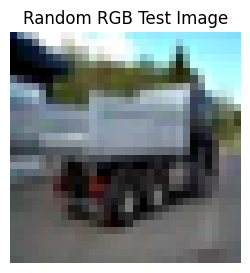

In [19]:
idx_rgb = random.randrange(x_test_rgb.shape[0])
plt.figure(figsize=(3, 3))
plt.imshow(x_test_rgb[idx_rgb].squeeze())
plt.axis('off')
plt.title('Random RGB Test Image')
plt.show()

### 8. Print the predicted class vs the original class

In [20]:
true_label_rgb = int(y_test_flat_cnn[idx_rgb])
pred_label_rgb = int(y_pred_rgb[idx_rgb])

print(f"Original Class (RGB): {cifar_labels[true_label_rgb]}")
print(f"Predicted Class (RGB): {cifar_labels[pred_label_rgb]}")

Original Class (RGB): truck
Predicted Class (RGB): automobile


### 9. Add one more conv layer and check if it increases the performance for the RGB images

In [27]:
inputs = keras.Input(shape=(32,32,3))
x = keras.layers.RandomFlip('horizontal')(inputs)
x = keras.layers.RandomRotation(0.04)(x)
x = keras.layers.RandomZoom(0.04)(x)

# Same base CNN as the RGB block, plus one extra conv layer
x = keras.layers.Conv2D(32, (3,3), padding='same', use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)
x = keras.layers.Dropout(0.15)(x)

x = keras.layers.Conv2D(64, (3,3), padding='same', use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)
x = keras.layers.Dropout(0.15)(x)

x = keras.layers.Conv2D(128, (3,3), padding='same', use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)
x = keras.layers.Dropout(0.15)(x)

# Extra convolution layer
x = keras.layers.Conv2D(128, (3,3), padding='same', use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.Dropout(0.4)(x)
outputs = keras.layers.Dense(10, activation='softmax')(x)

model_rgb_deep = keras.Model(inputs=inputs, outputs=outputs)

model_rgb_deep.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Reduce LR on training-loss plateau
reduce_lr_rgb_deep = keras.callbacks.ReduceLROnPlateau(monitor='loss', mode='min', factor=0.5, patience=15, min_lr=1e-6)
# Early stopping on training loss (no validation set)
early_stop_rgb_deep = keras.callbacks.EarlyStopping(monitor='loss', mode='min', patience=15, restore_best_weights=True, verbose=1)

# Train on full RGB training data
history_rgb_deep = model_rgb_deep.fit(
    x_train_rgb, y_train_flat_rgb,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict_rgb,
    callbacks=[early_stop_rgb_deep, reduce_lr_rgb_deep],
    verbose=1,
)

# Training loss and accuracy display
train_loss_rgb_deep, train_acc_rgb_deep = model_rgb_deep.evaluate(x_train_rgb, y_train_flat_rgb, verbose=0)
train_error_rgb_deep = 1 - np.exp(-train_loss_rgb_deep)
print(f"Training accuracy (RGB 4-Conv): {train_acc_rgb_deep:.4f}")
print(f"Training sparse CE loss (RGB 4-Conv): {train_loss_rgb_deep:.4f}")
print(f"Training smooth error 1-exp(-loss) (RGB 4-Conv): {train_error_rgb_deep:.4f}")

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.2872 - loss: 2.1149 - learning_rate: 0.0100
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3828 - loss: 1.7243 - learning_rate: 0.0100
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.4328 - loss: 1.6144 - learning_rate: 0.0100
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.4582 - loss: 1.5471 - learning_rate: 0.0100
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4698 - loss: 1.5262 - learning_rate: 0.0100
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5046 - loss: 1.4778 - learning_rate: 0.0100
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5140 - loss: 1.4629 - learning_rate: 0.0100
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5280 - loss: 1.4560 - learning_rate: 0.0100
Epoch 9/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5410 - loss: 1.4225 - learning_rate:

In [29]:
test_loss_rgb_deep, test_acc_rgb_deep = model_rgb_deep.evaluate(x_test_rgb, y_test_flat_cnn, verbose=0)
test_error_rgb_deep = 1 - np.exp(-test_loss_rgb_deep)

print(f"RGB (3-Conv):")
print(f"Test Accuracy: {test_acc_rgb:.4f}")
print(f"Test Sparse CE Loss: {test_loss_rgb:.4f}")
print(f"Test Smooth Error 1-exp(-loss): {test_error_rgb:.4f}")
print(f"\nRGB (4-Conv):")
print(f"Test Accuracy: {test_acc_rgb_deep:.4f}")
print(f"Test Sparse CE Loss: {test_loss_rgb_deep:.4f}")
print(f"Test Smooth Error 1-exp(-loss): {test_error_rgb_deep:.4f}")
print("\nChanges:")
acc_diff = test_acc_rgb_deep - test_acc_rgb
loss_diff = test_loss_rgb_deep - test_loss_rgb
error_diff = test_error_rgb_deep - test_error_rgb
acc_change = "improved" if acc_diff > 0 else ("decreased" if acc_diff < 0 else "unchanged")
loss_change = "decreased" if loss_diff < 0 else ("increased" if loss_diff > 0 else "unchanged")
error_change = "decreased" if error_diff < 0 else ("increased" if error_diff > 0 else "unchanged")
print(f"Accuracy: {acc_change} ({acc_diff:+.4f})")
print(f"Loss: {loss_change} ({loss_diff:+.4f})")
print(f"Smooth Error: {error_change} ({error_diff:+.4f})")

RGB (3-Conv):
Test Accuracy: 0.6690
Test Sparse CE Loss: 1.7151
Test Smooth Error 1-exp(-loss): 0.8200

RGB (4-Conv):
Test Accuracy: 0.7130
Test Sparse CE Loss: 1.5903
Test Smooth Error 1-exp(-loss): 0.7961

Changes:
Accuracy: improved (+0.0440)
Loss: decreased (-0.1247)
Smooth Error: decreased (-0.0239)


### 10. Use the next markup to write down your observations and reasonings on the performances of the models

*Observations -*

*About Models:*
1. Logistic Regression performed the worst because the image was flattened into a 1D vector. So, it could not learn image patterns like edges, shapes, and textures.

2. The grayscale CNN performed much better. CNN worked better because it can learn spatial features from images. But grayscale images lose color information, so performance was limited.

3. The RGB CNN performed better almost same as the grayscale CNN. This shows that color helped a little to the model classify CIFAR-10 images better.

4. The RGB CNN with one extra convolution layer improved accuracy huge. But the improvement was huge because CIFAR-10 images are small and extra layers can also make training better.

*Training*

If we could run for more epochs, the performance might be better. But the small size and low quality of the CIFAR-10 images made the training harder.

*Error*

The smooth error formula 1 - exp(-loss) keeps the error inside a 0 to 1 range. It is used for better vidualization.

In short, CNN models performed better than Logistic Regression. The extra convolution layer helped, and the improvement was huge.
